<a href="https://colab.research.google.com/github/EcTrailblazers/python-data-projects/blob/main/14_cpi_inflation_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

macro_history = """Month,CPI_Headline,Food_Inflation_MoM_%,Crude_Oil_MoM_%,Repo_Rate
2023-01,6.52,0.85,1.20,6.25
2023-02,6.44,0.72,-1.50,6.50
2023-03,5.66,-0.10,2.10,6.50
2023-04,4.70,-0.45,-4.20,6.50
2023-05,4.31,0.25,-2.80,6.50
2023-06,4.87,1.15,0.50,6.50
2023-07,7.44,3.20,4.80,6.50
2023-08,6.83,1.90,3.10,6.50
2023-09,5.02,-0.80,-1.20,6.50
2023-10,4.87,-0.20,-3.50,6.50
2023-11,5.55,0.90,1.80,6.50
2023-12,5.69,0.75,-1.10,6.50
2024-01,5.10,-0.30,-2.40,6.50
2024-02,5.09,0.15,1.10,6.50
2024-03,4.85,-0.10,2.30,6.50
2024-04,4.83,0.20,1.50,6.50
2024-05,4.75,0.10,-1.80,6.50
2024-06,5.08,0.95,3.20,6.50
2024-07,3.54,-1.80,-2.10,6.50
2024-08,3.65,0.25,-3.40,6.50
2024-09,5.49,2.10,-4.50,6.50
2024-10,6.21,1.80,2.10,6.50
2024-11,5.62,-0.40,-1.60,6.50
2024-12,5.22,-0.35,0.80,6.50
"""

with open("macro_forecasting_data.csv", "w") as f:
    f.write(macro_history.strip())

print("macro_forecasting_data.csv created successfully.")

macro_forecasting_data.csv created successfully.


In [2]:
df_cpi = pd.read_csv("macro_forecasting_data.csv")

# 1. Target variable: Headline CPI at period t
# 2. Lag features (t-1 and t-2)
df_cpi["CPI_Lag1"] = df_cpi["CPI_Headline"].shift(1)
df_cpi["CPI_Lag2"] = df_cpi["CPI_Headline"].shift(2)
df_cpi["Food_MoM_Lag1"] = df_cpi["Food_Inflation_MoM_%"].shift(1)
df_cpi["Crude_MoM_Lag1"] = df_cpi["Crude_Oil_MoM_%"].shift(1)

# Drop rows with NaN values created by lag shifts
df_model = df_cpi.dropna().reset_index(drop=True)

feature_cols = ["CPI_Lag1", "CPI_Lag2", "Food_MoM_Lag1", "Crude_MoM_Lag1"]
X = df_model[feature_cols]
y = df_model["CPI_Headline"]

print("--- Feature Matrix (X) Sample ---")
print(X.head())

--- Feature Matrix (X) Sample ---
   CPI_Lag1  CPI_Lag2  Food_MoM_Lag1  Crude_MoM_Lag1
0      6.44      6.52           0.72            -1.5
1      5.66      6.44          -0.10             2.1
2      4.70      5.66          -0.45            -4.2
3      4.31      4.70           0.25            -2.8
4      4.87      4.31           1.15             0.5


In [3]:
# Train-Test Split: 75% historical training, 25% out-of-sample forward test
split_idx = int(len(df_model) * 0.75)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
test_periods = df_model["Month"].iloc[split_idx:].values

# 1. Fit Ordinary Least Squares (OLS) Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# 2. Fit Regularized Ridge Regression (prevents collinear overfitting)
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

# Model Performance Evaluation
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print("--- Out-of-Sample Forecasting Diagnostics ---")
print(f"Linear Regression -> MAE: {mae_lr:.3f} | RMSE: {rmse_lr:.3f} | R2: {r2_lr:.3f}")
print(f"Ridge Regression  -> MAE: {mae_ridge:.3f} | RMSE: {rmse_ridge:.3f}")

# Inspect Feature Coefficients
coef_df = pd.DataFrame(
    {"Feature": feature_cols, "Weight_Impact": lr_model.coef_}
).sort_values(by="Weight_Impact", ascending=False)
print("\n--- Model Feature Coefficients ---")
print(coef_df.round(3))

--- Out-of-Sample Forecasting Diagnostics ---
Linear Regression -> MAE: 0.752 | RMSE: 0.964 | R2: 0.082
Ridge Regression  -> MAE: 0.711 | RMSE: 0.942

--- Model Feature Coefficients ---
          Feature  Weight_Impact
2   Food_MoM_Lag1          0.487
0        CPI_Lag1          0.160
3  Crude_MoM_Lag1         -0.049
1        CPI_Lag2         -0.373


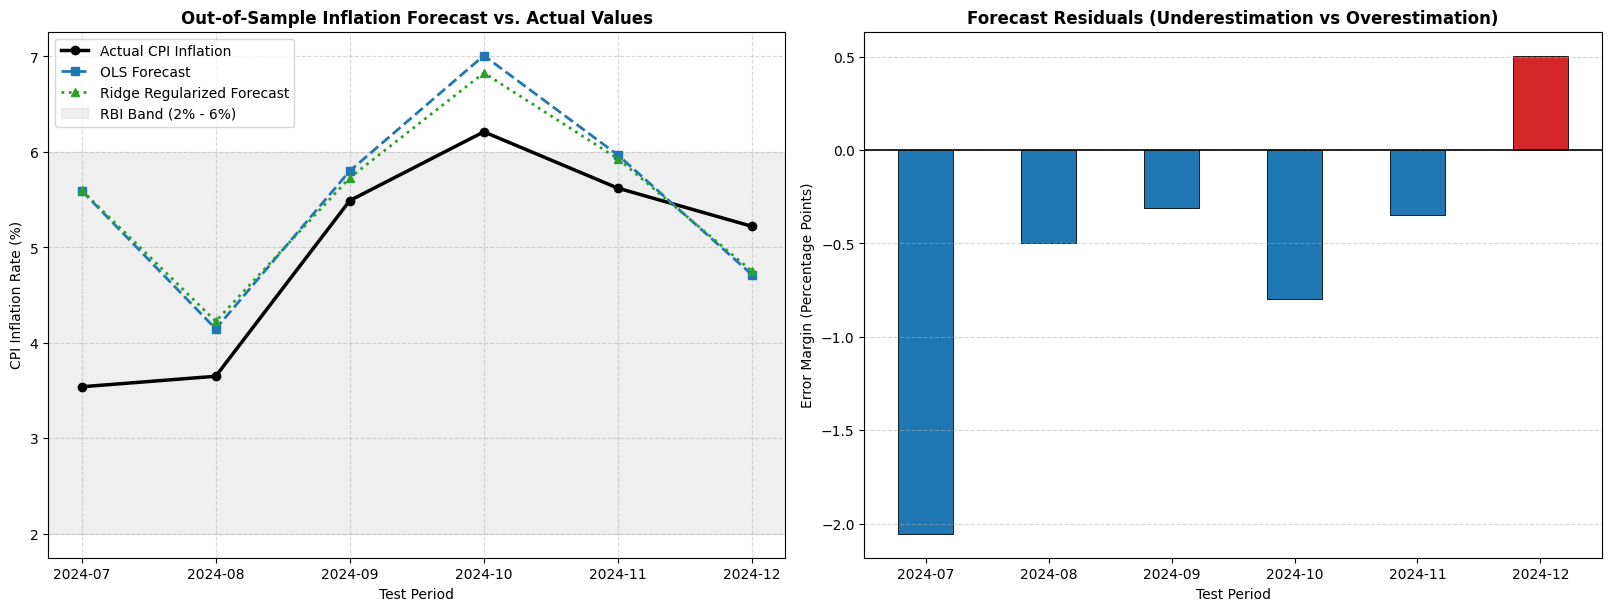

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), layout="constrained")

# --- Chart 1: Actual vs. Forecasted Inflation Path ---
test_indices = np.arange(len(test_periods))

ax1.plot(
    test_periods,
    y_test.values,
    label="Actual CPI Inflation",
    color="black",
    marker="o",
    linewidth=2.5,
)
ax1.plot(
    test_periods,
    y_pred_lr,
    label="OLS Forecast",
    color="#1f77b4",
    marker="s",
    linestyle="--",
    linewidth=2,
)
ax1.plot(
    test_periods,
    y_pred_ridge,
    label="Ridge Regularized Forecast",
    color="#2ca02c",
    marker="^",
    linestyle=":",
    linewidth=2,
)

# Reference band for RBI MPC tolerance
ax1.axhspan(2.0, 6.0, color="gray", alpha=0.12, label="RBI Band (2% - 6%)")
ax1.set_title("Out-of-Sample Inflation Forecast vs. Actual Values", fontsize=12, weight="bold")
ax1.set_xlabel("Test Period")
ax1.set_ylabel("CPI Inflation Rate (%)")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="upper left")

# --- Chart 2: Forecast Residuals (Prediction Error) ---
residuals = y_test.values - y_pred_lr

bar_colors = ["#d62728" if res > 0 else "#1f77b4" for res in residuals]
ax2.bar(
    test_periods,
    residuals,
    color=bar_colors,
    edgecolor="black",
    linewidth=0.6,
    width=0.45,
)
ax2.axhline(0, color="black", linewidth=1.2)
ax2.set_title("Forecast Residuals (Underestimation vs Overestimation)", fontsize=12, weight="bold")
ax2.set_xlabel("Test Period")
ax2.set_ylabel("Error Margin (Percentage Points)")
ax2.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()